In [1]:
#!/bin/bash
!curl -L -o customer-segmentation-tutorial-in-python.zip\
  https://www.kaggle.com/api/v1/datasets/download/vjchoudhary7/customer-segmentation-tutorial-in-python

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1583  100  1583    0     0   3977      0 --:--:-- --:--:-- --:--:--  3977


In [2]:
!unzip /content/customer-segmentation-tutorial-in-python.zip

Archive:  /content/customer-segmentation-tutorial-in-python.zip
  inflating: Mall_Customers.csv      


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [5]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
# We only need the 'Annual Income (k$)' and 'Spending Score (1-100)' columns
X = df.iloc[:, [3,4]].values
print(X[:5])

[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
X_scaled = scaler.fit_transform(X)

In [12]:
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [13]:
from sklearn.cluster import KMeans

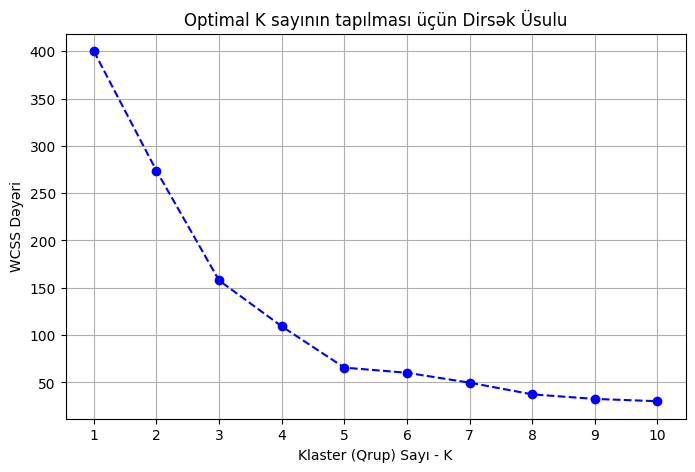

In [14]:
wcss = []

for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Optimal K sayının tapılması üçün Dirsək Üsulu')
plt.xlabel('Klaster (Qrup) Sayı - K')
plt.ylabel('WCSS Dəyəri')
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [16]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [18]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


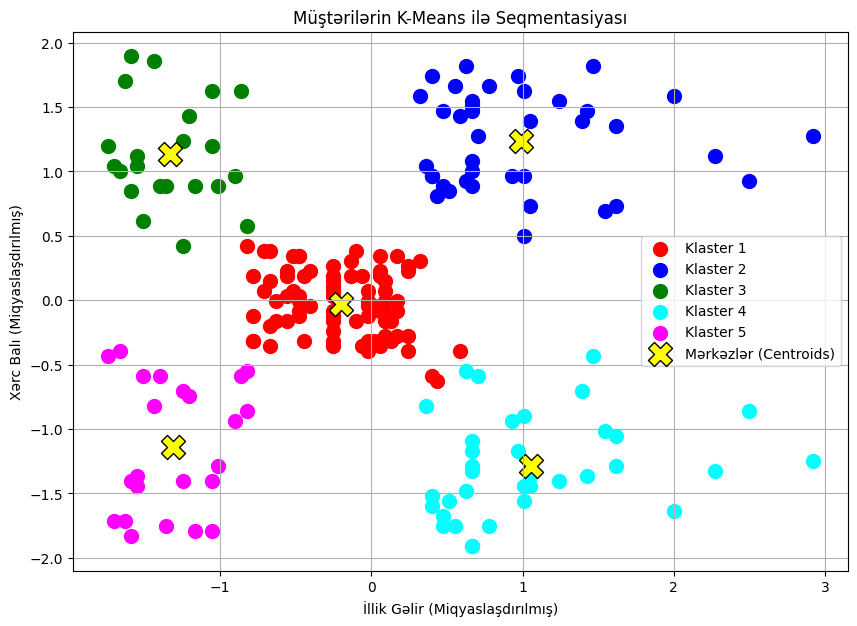

In [19]:
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']
cluster_labels = ['Klaster 1', 'Klaster 2', 'Klaster 3', 'Klaster 4', 'Klaster 5']

for i in range(5):
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=cluster_labels[i])

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Mərkəzlər (Centroids)', marker='X', edgecolors='black')

plt.title('Müştərilərin K-Means ilə Seqmentasiyası')
plt.xlabel('İllik Gəlir (Miqyaslaşdırılmış)')
plt.ylabel('Xərc Balı (Miqyaslaşdırılmış)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

In [21]:
sil_score = silhouette_score(X_scaled, y_kmeans)

In [23]:
print(sil_score)

0.5546571631111091
